In [1]:
using Pkg
Pkg.activate(".")

using GLMakie, NPZ, FFTW, LinearAlgebra

  Activating project at `~/radio-imaging/notebooks_and_pyscripts`
[ Info: Precompiling GLMakie [e9467ef8-e4e7-5192-8a1a-b1aee30e663a] (cache misses: invalid header (2))
┌ Warning: attempting to remove probably stale pidfile
│   path = "/home/sunwang/.julia/compiled/v1.11/Makie/iZ1Bl_D1Nvg.ji.pidfile"
└ @ FileWatching.Pidfile /snap/julia/108/share/julia/stdlib/v1.11/FileWatching/src/pidfile.jl:249
[ Info: Precompiling NPZ [15e1cf62-19b3-5cfa-8e77-841668bca605] (cache misses: invalid header (2))


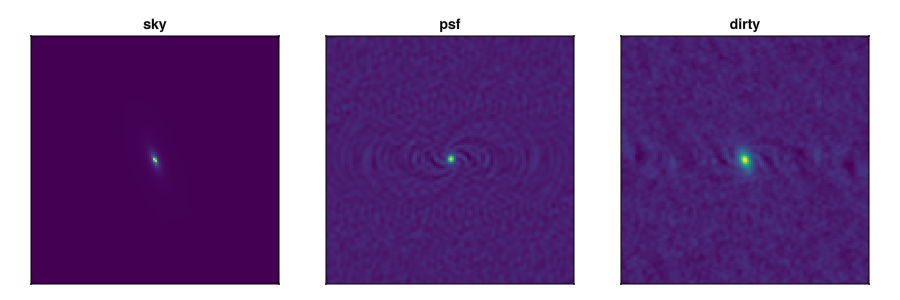

In [2]:
num_sky = 2
psf = npzread("psf.npy")
sky = npzread("true.npy")[num_sky,:,:]
dirty_low = npzread("dirty_low_noise.npy")[num_sky,:,:]
dirty_high = npzread("dirty_proper_noise.npy")[num_sky,:,:]

fig = Figure(; size = (900, 300))
ax1 = Axis(fig[1, 1], title="sky", aspect=DataAspect())
ax2 = Axis(fig[1, 2], title="psf", aspect=DataAspect())
ax3 = Axis(fig[1, 3], title="dirty", aspect=DataAspect())
heatmap!(ax1, sky)
heatmap!(ax2, psf)
heatmap!(ax3, dirty_low)

hidedecorations!(ax1)
hidedecorations!(ax2)
hidedecorations!(ax3)
fig

In [3]:
imfilter(img, psf) = real.(ifft(fft(img).*fft(ifftshift(psf))))
adj(psf) = circshift(reverse(psf), ntuple(i -> 1, ndims(psf)))

adj (generic function with 1 method)

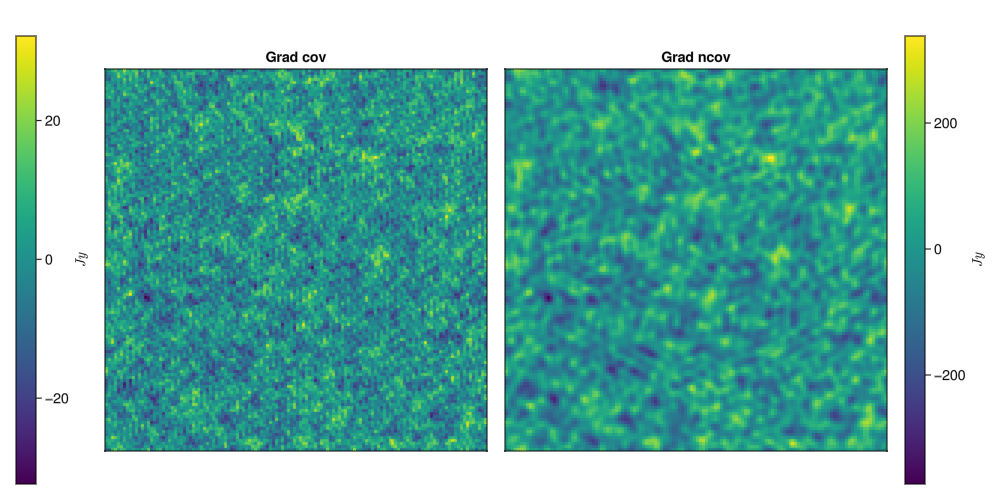

In [30]:
pinv_psf = real.(ifft(map(x -> isapprox(x, 0., atol=1e-4) ? 0 : 1/x, real.(fft(psf)))));  # pseudo inverse

psf_adj = adj(psf)
psf3 = imfilter(imfilter(pinv_psf, psf), psf_adj)
H3id = imfilter(dirty_low, imfilter(pinv_psf, psf_adj))

psf2 = imfilter(psf, psf_adj)
H2id = imfilter(dirty_low, psf_adj)

# compute the gradient
σ² = 1
∇f_cov(i_) = (2/σ²)*(imfilter(i_, psf3) - H3id)
∇f_nocov(i_) = (2/σ²)*(imfilter(i_, psf2) - H2id)

i_ = dirty_low + randn(size(dirty_low))

fig = Figure(; size = (1000, 500))
ax1 = Axis(fig[1, 1], title="Grad cov", aspect=DataAspect())
ax2 = Axis(fig[1, 2], title="Grad ncov", aspect=DataAspect())
hm1 = heatmap!(ax1,  ∇f_cov(i_))
Colorbar(fig[1, 0], hm1, label = L"Jy", width = 20, labelsize = 14, ticklabelsize = 14)
hm2 = heatmap!(ax2, ∇f_nocov(i_))
Colorbar(fig[1, 3], hm2, label = L"Jy", width = 20, labelsize = 14, ticklabelsize = 14)
hidedecorations!(ax1)
hidedecorations!(ax2)
fig